# Imports

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, label, binary_dilation, binary_closing, gaussian_filter

In [14]:
CROP_BOTTOM = 70

# Background detection parameters
BG_TILE_SIZE          = 10
BG_STD_THRESHOLD      = 5
BG_MIN_REGION_SIZE    = 50
BG_MIN_CONTRAST_RATIO = 20.0
BG_MAX_REGION_MEAN    = 0.1   # tiles in true empty substrate have edge-std ≈ 0;
                               # biofilm matrix between bacteria has mean 0.2–0.9

# Texture analysis parameters
MATRIX_TILE_SIZE     = 100
VMIN, VMAX           = 5, 80
HEATMAP_SMOOTH_SIGMA = 15


# Upload Image

- Using SEM images with 20,000 magnification
- 18 images per treatment

[ WARN:0@275.452] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34682 (0x877a) encountered


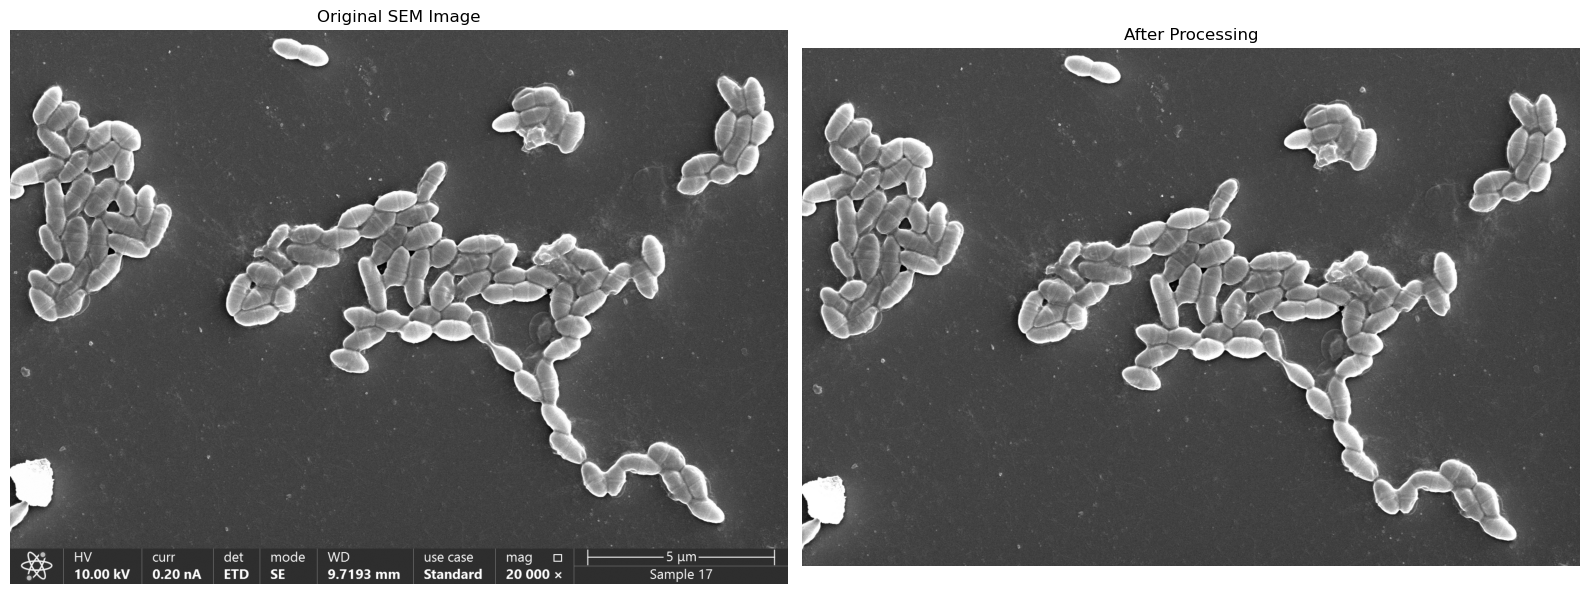

In [15]:
path = "./data/50 ug:ml/20000/Sample 17_10.tif"   
# path = './data/control/20000/Sample 1_10.tif'

img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

original = img[:-CROP_BOTTOM, :]

# Display both original and cropped for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original SEM Image')
axes[0].axis('off')

axes[1].imshow(original, cmap='gray')
axes[1].set_title('After Processing')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# EDGE DETECTION

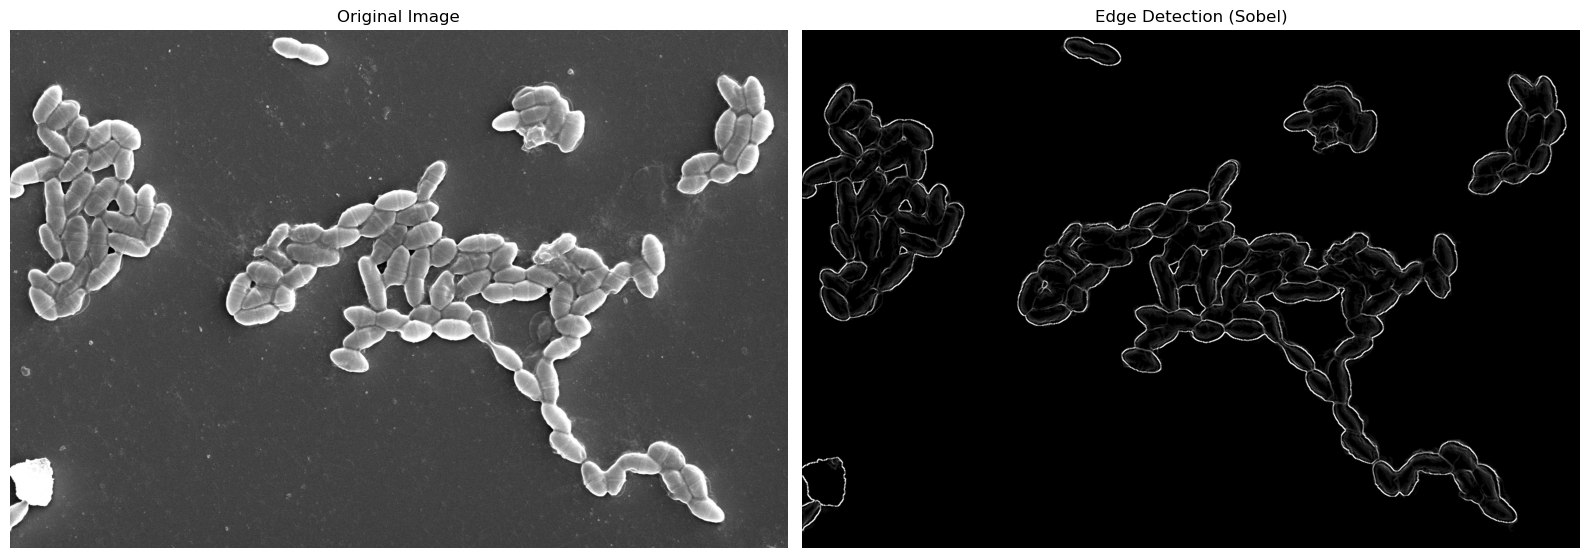

In [16]:
def compute_edges(img):
    """Smooth image and apply Sobel edge detection."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel, iterations=2)

    wls = cv2.ximgproc.createFastGlobalSmootherFilter(opened, lambda_=10, sigma_color=10)
    smoothed = wls.filter(opened)

    sobel_x = cv2.Sobel(smoothed, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(smoothed, cv2.CV_64F, 0, 1, ksize=3)
    edges = cv2.addWeighted(
        cv2.convertScaleAbs(sobel_x), 0.5,
        cv2.convertScaleAbs(sobel_y), 0.5, 0
    )

    # Remove small isolated edge blobs (debris/noise artifacts)
    _, binary = cv2.threshold(edges, 10, 255, cv2.THRESH_BINARY)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    min_area = 500  # bacteria edge loops are much larger than debris spots
    clean_mask = np.zeros_like(binary)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            clean_mask[labels == i] = 255

    edges = cv2.bitwise_and(edges, edges, mask=clean_mask)
    return edges

edges = compute_edges(original)

# Visualize edges
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Edge Detection (Sobel)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# BACKGROUND DETECTION

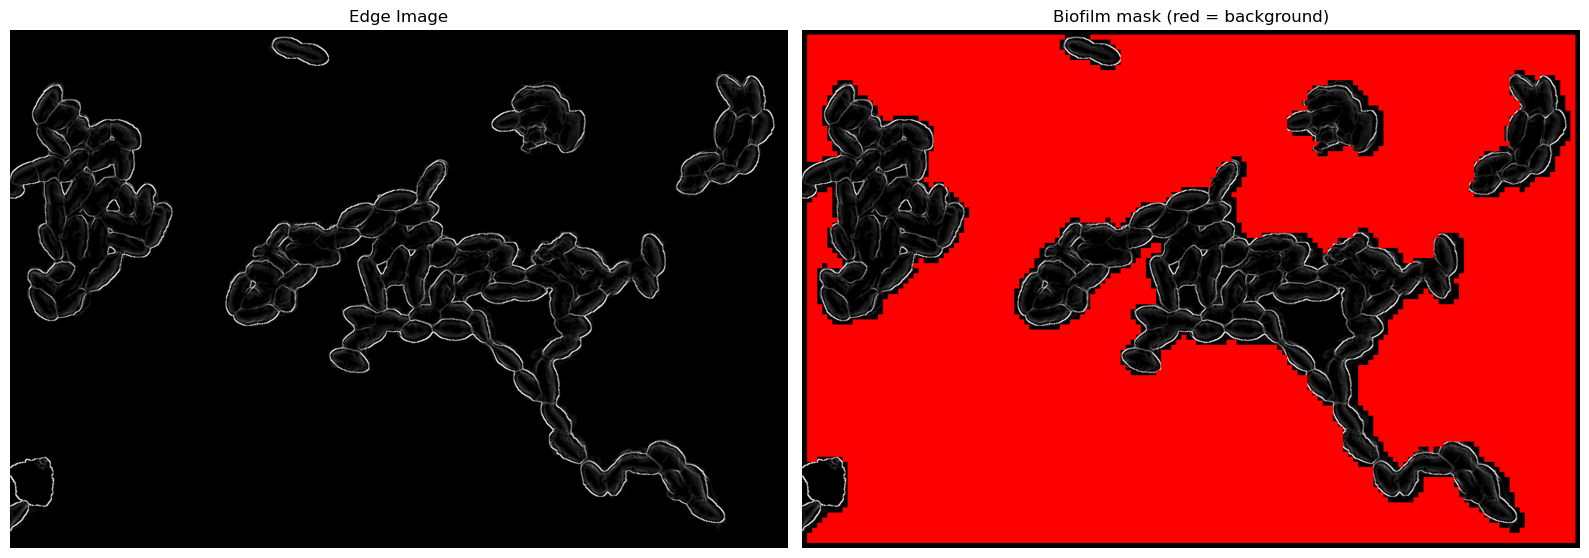

In [17]:
def get_biofilm_mask(img):
    """Detect biofilm regions using tile-based variance analysis."""
    size = BG_TILE_SIZE
    h, w = img.shape

    scores = np.array([
        [np.std(img[i*size:(i+1)*size, j*size:(j+1)*size])
         for j in range(w // size)]
        for i in range(h // size)
    ])

    low_variance = scores < BG_STD_THRESHOLD
    if np.sum(low_variance) == 0:
        return np.ones(img.shape, dtype=bool)

    labeled_regions, num_regions = label(low_variance)
    background_mask = np.zeros_like(low_variance, dtype=bool)

    for region_id in range(1, num_regions + 1):
        region_mask = labeled_regions == region_id
        region_size = np.sum(region_mask)
        if region_size < BG_MIN_REGION_SIZE:
            continue

        region_mean   = np.mean(scores[region_mask])

        # Reject regions whose tiles carry any real edge content — those are
        # biofilm matrix gaps between bacteria, not empty substrate background.
        if region_mean > BG_MAX_REGION_MEAN:
            continue

        region_coords = np.where(region_mask)
        touches_edge  = (
            np.min(region_coords[0]) == 0 or
            np.max(region_coords[0]) == scores.shape[0] - 1 or
            np.min(region_coords[1]) == 0 or
            np.max(region_coords[1]) == scores.shape[1] - 1
        )

        border = binary_dilation(region_mask, iterations=1) & ~region_mask
        contrast_ratio = (
            np.mean(scores[border]) / region_mean
            if np.sum(border) > 0 and region_mean > 0 else 0
        )
        is_sudden = contrast_ratio >= BG_MIN_CONTRAST_RATIO

        if is_sudden and ((region_size >= 5 and touches_edge) or region_size >= 10):
            background_mask[region_mask] = True

    bg_mask_tiles = binary_closing(background_mask, iterations=1)

    upsampled = zoom(
        bg_mask_tiles.astype(float),
        np.array(img.shape) / (np.array(bg_mask_tiles.shape) * size),
        order=0
    )
    bg_mask = cv2.resize(
        upsampled.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST
    ).astype(bool)

    return ~bg_mask

biofilm_mask = get_biofilm_mask(edges)

# Visualize background
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(edges, cmap='gray')
axes[0].set_title('Edge Image')
axes[0].axis('off')

gray_norm = (edges.astype(float) / edges.max() * 255).astype(np.uint8)
overlay = np.stack([gray_norm, gray_norm, gray_norm], axis=-1)
overlay[~biofilm_mask] = [255, 0, 0]   # background = red
axes[1].imshow(overlay)
axes[1].set_title('Biofilm mask (red = background)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


# Biofilm Stracture Analysis

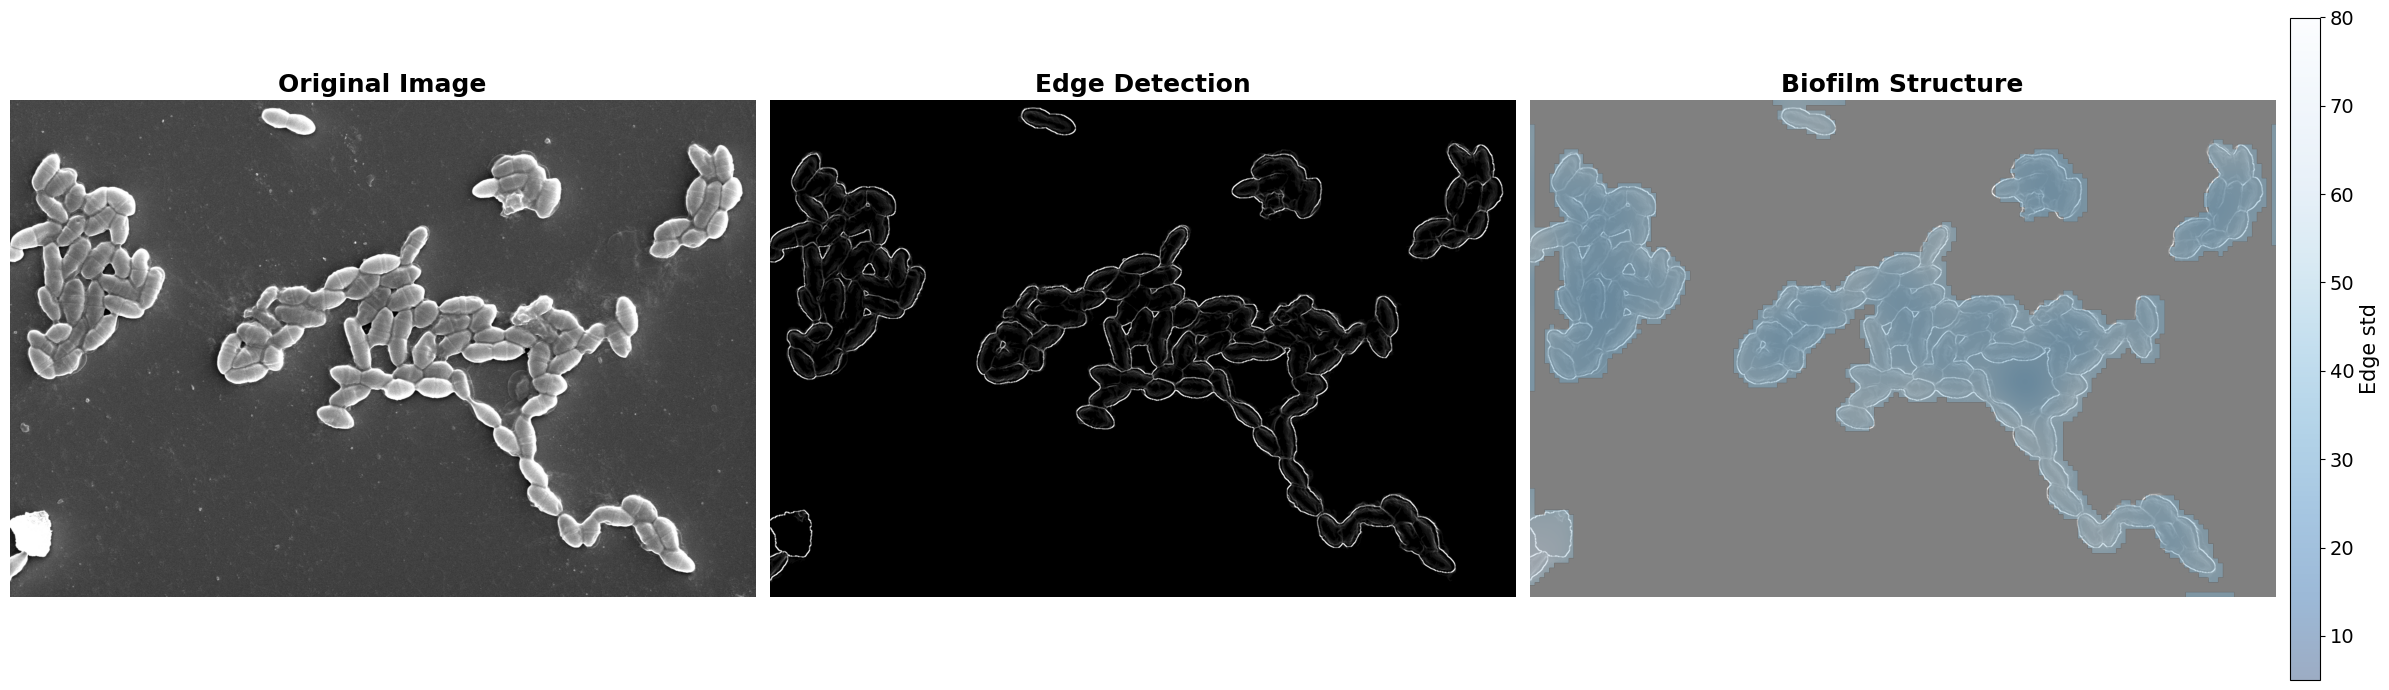

In [18]:
def analyze_tiles(edge_img, biofilm_mask, tile_size=MATRIX_TILE_SIZE,
                  stride=None, build_heatmap=True):
    """Tile-based texture analysis on edge image."""
    if stride is None:
        stride = tile_size // 2

    h, w = edge_img.shape
    pad  = tile_size // 2

    img_padded  = np.pad(edge_img,     pad, mode='reflect')
    mask_padded = np.pad(biofilm_mask, pad, mode='constant', constant_values=False)
    h_p, w_p = img_padded.shape

    tile_values = []

    if build_heatmap:
        score_acc  = np.zeros((h_p, w_p), dtype=np.float32)
        weight_acc = np.zeros((h_p, w_p), dtype=np.float32)
        center = tile_size // 2
        y, x   = np.ogrid[0:tile_size, 0:tile_size]
        weight_kernel = np.exp(
            -((y - center) ** 2 + (x - center) ** 2) / (2 * (tile_size / 3) ** 2)
        )

    for yi in range(0, h_p - tile_size + 1, stride):
        for xi in range(0, w_p - tile_size + 1, stride):
            tile_mask = mask_padded[yi:yi + tile_size, xi:xi + tile_size]
            if np.sum(tile_mask) / (tile_size * tile_size) <= 0.3:
                continue

            biofilm_pixels = img_padded[yi:yi + tile_size, xi:xi + tile_size][tile_mask]
            if len(biofilm_pixels) == 0:
                continue

            std = np.std(biofilm_pixels)
            tile_values.append(std)

            if build_heatmap:
                wstd = weight_kernel * std
                wstd[~tile_mask] = 0
                wc = weight_kernel.copy()
                wc[~tile_mask] = 0
                score_acc[yi:yi + tile_size,  xi:xi + tile_size] += wstd
                weight_acc[yi:yi + tile_size, xi:xi + tile_size] += wc

    tile_values = np.array(tile_values)

    if not build_heatmap:
        return tile_values

    scores = np.full((h_p, w_p), np.nan, dtype=np.float32)
    valid  = weight_acc > 0.01
    scores[valid] = score_acc[valid] / weight_acc[valid]
    scores = scores[pad:pad + h, pad:pad + w]
    scores[~biofilm_mask] = np.nan

    return scores, tile_values


def smooth_heatmap(scores, sigma=HEATMAP_SMOOTH_SIGMA):
    """Apply Gaussian smoothing while preserving NaN boundaries."""
    mask = ~np.isnan(scores)
    if not np.any(mask):
        return scores

    scores_filled = scores.copy()
    scores_filled[~mask] = np.nanmean(scores)
    smoothed = gaussian_filter(scores_filled.astype(float), sigma=sigma)
    smoothed[~mask] = np.nan
    return smoothed

scores_raw, kernel_values = analyze_tiles(edges, biofilm_mask)
scores_smoothed = smooth_heatmap(scores_raw)
tile_values = analyze_tiles(
    edges, biofilm_mask, stride=MATRIX_TILE_SIZE, build_heatmap=False
)

fig, axes = plt.subplots(1, 4, figsize=(24, 7), gridspec_kw={'width_ratios': [1, 1, 1, 0.04]})

axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original Image', fontsize=18, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Edge Detection', fontsize=18, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(edges, cmap='gray', alpha=0.5)
masked = np.ma.masked_where(np.isnan(scores_smoothed), scores_smoothed)
im2 = axes[2].imshow(masked, cmap='Blues_r', vmin=VMIN, vmax=VMAX,
                     alpha=0.4, interpolation='bilinear')
axes[2].set_title('Biofilm Structure', fontsize=18, fontweight='bold')
axes[2].axis('off')

cbar = plt.colorbar(im2, cax=axes[3], label='Edge std')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Edge std', fontsize=15)

plt.tight_layout()
plt.show()